# Contact-Aware Control of a 5-DOF Robotic Manipulator using Impedance and Admittance Strategies

This notebook studies how a 5-DOF serial manipulator interacts with a compliant environment. The objective is to compare impedance and admittance control in terms of motion behavior, force response, and compliance during contact.

The project is motivated by robotic applications in which free-space tracking is not sufficient and the robot must interact safely and effectively with the environment. This includes manipulation, human-robot interaction, tool guidance, and medical robotics.

## Environment contact model

The environment is modeled as a compliant wall using a spring-damper contact law. When the end-effector penetrates the wall, the wall generates a restoring force proportional to the penetration depth and the velocity along the wall normal direction.

This type of model captures the essential physics of soft contact while remaining simple enough for simulation and controller comparison.

## Impedance control

Impedance control imposes a virtual mechanical relationship between the desired position and the actual end-effector motion. In this notebook, the controller generates a Cartesian force using a virtual spring-damper law, and that force is mapped to joint torques through the Jacobian transpose.

This strategy is useful when the goal is to achieve compliant behavior directly through motion error.
## Admittance control

Admittance control modifies the reference motion based on the measured interaction force. Instead of commanding the robot to move directly to the nominal desired point, the controller updates a compliant reference trajectory according to a virtual mass-spring-damper model driven by contact force.

This is useful when force information is available and compliant motion should emerge through reference adaptation.

Initial EE position: [ 5.51071082e-01 -1.66419080e-17 -3.17829834e-02]
Desired EE position: [ 0.73107108  0.08       -0.06178298]
Wall position x = 0.48

Impedance metrics:
rms_position_error: 0.181933
max_contact_force: 576.920866
mean_contact_force: 528.369025
max_penetration: 0.189790
torque_energy: 4837.087009

Admittance metrics:
rms_position_error: 0.242430
max_contact_force: 2745.856861
mean_contact_force: 34.900071
max_penetration: 0.168886
torque_energy: 98969128.439123


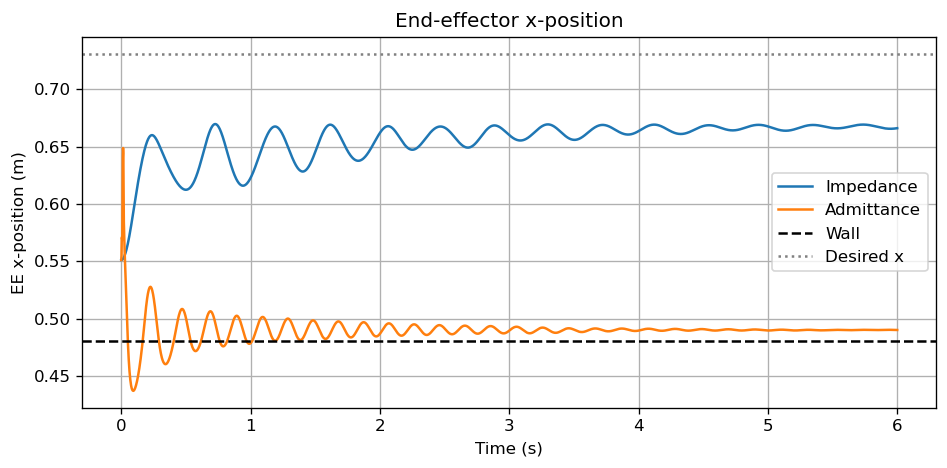

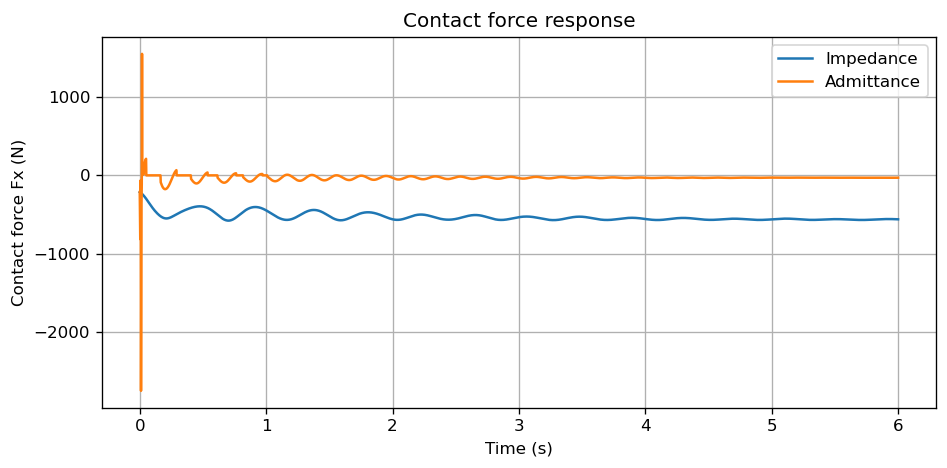

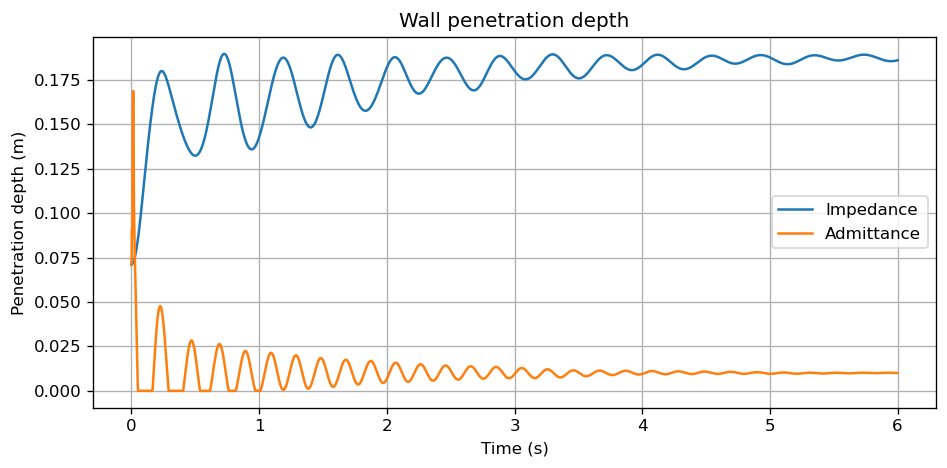

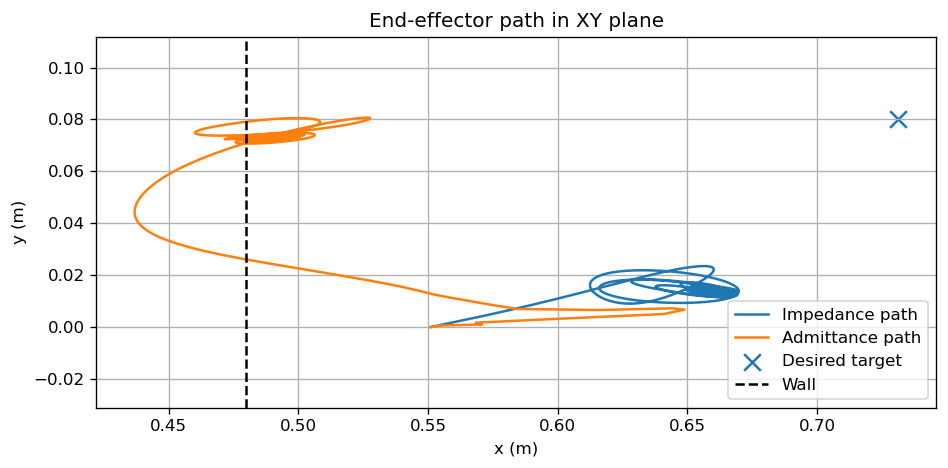

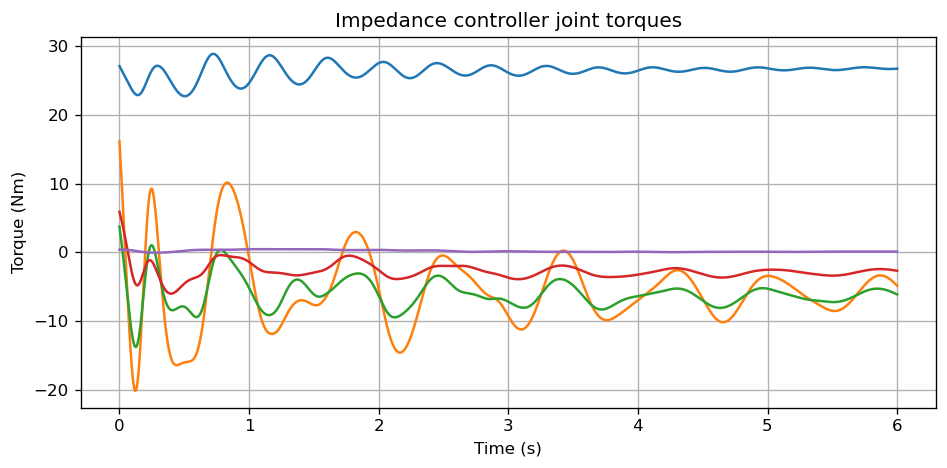

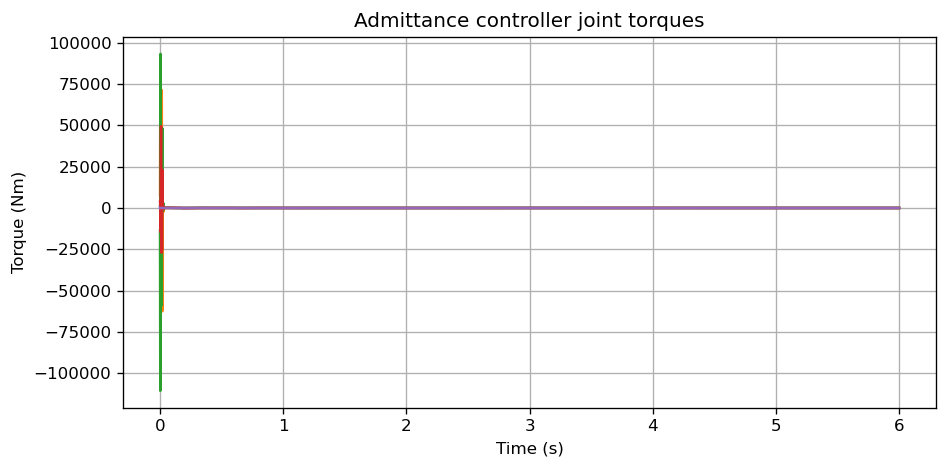

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 120

# ============================================================
# 1. CONFIGURATION
# ============================================================

DT = 0.002
T_FINAL = 6.0
N_STEPS = int(T_FINAL / DT)
t = np.linspace(0, T_FINAL, N_STEPS)

DH_PARAMS = [
    [0.0,      np.pi/2,  0.12, 0.0],
    [0.30,     0.0,      0.00, 0.0],
    [0.25,     0.0,      0.00, 0.0],
    [0.0,      np.pi/2,  0.00, 0.0],
    [0.0,      0.0,      0.12, 0.0],
]

LINK_MASSES = np.array([4.0, 3.5, 2.5, 1.5, 0.8])
LINK_LENGTHS = np.array([0.12, 0.30, 0.25, 0.10, 0.12])
INERTIA_DIAG = np.array([1.5, 1.2, 0.8, 0.25, 0.12])
FRICTION = np.array([0.8, 0.7, 0.5, 0.2, 0.1])
GRAVITY = 9.81

Q0 = np.array([0.0, -0.5, 0.9, 0.1, 0.0])
QDOT0 = np.zeros(5)

# Cartesian impedance gains
KX = np.diag([250.0, 180.0, 180.0])
DX = np.diag([35.0, 25.0, 25.0])

# Admittance gains
MA = np.diag([2.0, 2.0, 2.0])
DA = np.diag([45.0, 45.0, 45.0])
KA = np.diag([120.0, 120.0, 120.0])

# Joint-space low-level gains for admittance tracking
KP_J = np.diag([120, 140, 120, 60, 40])
KD_J = np.diag([18, 22, 18, 8, 6])

# Wall parameters
X_WALL = 0.48
K_ENV = 3000.0
B_ENV = 80.0

# ============================================================
# 2. KINEMATICS
# ============================================================

def dh_transform(a, alpha, d, theta):
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [0.0,    sa,     ca,    d],
        [0.0,   0.0,    0.0,  1.0]
    ])

def forward_kinematics(q, dh_params):
    T = np.eye(4)
    Ts = [T.copy()]
    for i, qi in enumerate(q):
        a, alpha, d, theta_offset = dh_params[i]
        T = T @ dh_transform(a, alpha, d, qi + theta_offset)
        Ts.append(T.copy())
    return Ts

def end_effector_position(q, dh_params):
    return forward_kinematics(q, dh_params)[-1][:3, 3]

def jacobian_geometric(q, dh_params):
    Ts = forward_kinematics(q, dh_params)
    n = len(q)
    o_n = Ts[-1][:3, 3]

    Jv = np.zeros((3, n))
    Jw = np.zeros((3, n))

    for i in range(n):
        z_i = Ts[i][:3, 2]
        o_i = Ts[i][:3, 3]
        Jv[:, i] = np.cross(z_i, o_n - o_i)
        Jw[:, i] = z_i

    return np.vstack((Jv, Jw))

def ik_damped_least_squares(x_target, q_init, dh_params, max_iters=300, alpha=0.4, damping=1e-3, tol=1e-4):
    q = q_init.copy()
    for _ in range(max_iters):
        x = end_effector_position(q, dh_params)
        e = x_target - x
        if np.linalg.norm(e) < tol:
            break
        J = jacobian_geometric(q, dh_params)[:3, :]
        dq = J.T @ np.linalg.solve(J @ J.T + (damping**2) * np.eye(3), e)
        q = q + alpha * dq
    return q

# ============================================================
# 3. DYNAMICS
# ============================================================

def mass_matrix(q, inertia_diag):
    n = len(q)
    M = np.diag(inertia_diag + 0.12*np.abs(np.cos(q)))
    for i in range(n-1):
        coupling = 0.025*np.cos(q[i] - q[i+1])
        M[i, i+1] = coupling
        M[i+1, i] = coupling
    return M

def coriolis_vector(q, qdot):
    n = len(q)
    c = np.zeros(n)
    for i in range(n):
        c[i] = 0.05*np.sin(q[i]) * qdot[i]
    for i in range(n-1):
        c[i] += 0.02*(qdot[i+1]**2)*np.sin(q[i] - q[i+1])
    return c

def gravity_vector(q, link_masses, link_lengths, g=9.81):
    n = len(q)
    G = np.zeros(n)
    for i in range(n):
        torque_i = 0.0
        for j in range(i, n):
            accum_angle = np.sum(q[:j+1])
            lever = 0.5*link_lengths[j] if j == i else link_lengths[j]
            torque_i += link_masses[j] * g * lever * np.cos(accum_angle)
        G[i] = torque_i
    return G

def friction_vector(qdot, friction):
    return friction * qdot

def forward_dynamics(q, qdot, tau, tau_contact=None):
    if tau_contact is None:
        tau_contact = np.zeros_like(q)

    M = mass_matrix(q, INERTIA_DIAG)
    C = coriolis_vector(q, qdot)
    G = gravity_vector(q, LINK_MASSES, LINK_LENGTHS)
    F = friction_vector(qdot, FRICTION)

    qdd = np.linalg.solve(M, tau - tau_contact - C - G - F)
    return qdd

def rk4_step(q, qdot, tau, tau_contact, dt):
    def f(state):
        qq = state[:len(q)]
        qd = state[len(q):]
        qdd = forward_dynamics(qq, qd, tau, tau_contact)
        return np.hstack((qd, qdd))

    x = np.hstack((q, qdot))
    k1 = f(x)
    k2 = f(x + 0.5*dt*k1)
    k3 = f(x + 0.5*dt*k2)
    k4 = f(x + dt*k3)

    x_next = x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return x_next[:len(q)], x_next[len(q):]

# ============================================================
# 4. CONTACT MODEL
# ============================================================

def contact_force(x_ee, xdot_ee, x_wall=X_WALL, k_env=K_ENV, b_env=B_ENV):
    """
    Wall normal is +x direction.
    Contact occurs when EE penetrates wall: x_ee[0] > x_wall
    Force acts in -x direction.
    """
    penetration = x_ee[0] - x_wall
    if penetration > 0:
        fx = -k_env * penetration - b_env * xdot_ee[0]
        return np.array([fx, 0.0, 0.0]), penetration
    else:
        return np.zeros(3), 0.0

# ============================================================
# 5. CONTROLLERS
# ============================================================

def impedance_control(q, qdot, x_des):
    J = jacobian_geometric(q, DH_PARAMS)
    Jv = J[:3, :]
    x = end_effector_position(q, DH_PARAMS)
    xdot = Jv @ qdot

    e = x_des - x
    edot = -xdot  # desired Cartesian velocity = 0

    F_cmd = KX @ e + DX @ edot
    tau = Jv.T @ F_cmd + gravity_vector(q, LINK_MASSES, LINK_LENGTHS)
    return tau, x, xdot

def admittance_reference_update(x_ref, x_ref_dot, x_des, F_contact, dt):
    # M_a xdd + D_a xd + K_a (x_ref - x_des) = F_contact
    rhs = F_contact - DA @ x_ref_dot - KA @ (x_ref - x_des)
    x_ref_ddot = np.linalg.solve(MA, rhs)

    x_ref_dot_new = x_ref_dot + dt * x_ref_ddot
    x_ref_new = x_ref + dt * x_ref_dot_new
    return x_ref_new, x_ref_dot_new, x_ref_ddot

def joint_pd_gravity_control(q, qdot, qd, qd_dot):
    e = qd - q
    edot = qd_dot - qdot
    tau = KP_J @ e + KD_J @ edot + gravity_vector(q, LINK_MASSES, LINK_LENGTHS)
    return tau

# ============================================================
# 6. SIMULATION FUNCTIONS
# ============================================================

def run_impedance_sim(q0, qdot0, x_des):
    q = q0.copy()
    qdot = qdot0.copy()

    q_hist = np.zeros((N_STEPS, 5))
    tau_hist = np.zeros((N_STEPS, 5))
    ee_hist = np.zeros((N_STEPS, 3))
    force_hist = np.zeros((N_STEPS, 3))
    pen_hist = np.zeros(N_STEPS)

    for k in range(N_STEPS):
        tau_cmd, x_ee, xdot_ee = impedance_control(q, qdot, x_des)
        F_contact, pen = contact_force(x_ee, xdot_ee)
        Jv = jacobian_geometric(q, DH_PARAMS)[:3, :]
        tau_contact = Jv.T @ F_contact

        q, qdot = rk4_step(q, qdot, tau_cmd, tau_contact, DT)

        q_hist[k] = q
        tau_hist[k] = tau_cmd
        ee_hist[k] = x_ee
        force_hist[k] = F_contact
        pen_hist[k] = pen

    return {
        "q": q_hist,
        "tau": tau_hist,
        "ee": ee_hist,
        "force": force_hist,
        "penetration": pen_hist
    }

def run_admittance_sim(q0, qdot0, x_des):
    q = q0.copy()
    qdot = qdot0.copy()

    x_ref = x_des.copy()
    x_ref_dot = np.zeros(3)

    q_hist = np.zeros((N_STEPS, 5))
    tau_hist = np.zeros((N_STEPS, 5))
    ee_hist = np.zeros((N_STEPS, 3))
    force_hist = np.zeros((N_STEPS, 3))
    pen_hist = np.zeros(N_STEPS)
    xref_hist = np.zeros((N_STEPS, 3))

    q_ref_prev = q.copy()

    for k in range(N_STEPS):
        x_ee = end_effector_position(q, DH_PARAMS)
        Jv = jacobian_geometric(q, DH_PARAMS)[:3, :]
        xdot_ee = Jv @ qdot

        F_contact, pen = contact_force(x_ee, xdot_ee)

        # Update compliant Cartesian reference from measured force
        x_ref, x_ref_dot, _ = admittance_reference_update(x_ref, x_ref_dot, x_des, F_contact, DT)

        # Cartesian reference -> joint reference via IK
        q_ref = ik_damped_least_squares(x_ref, q.copy(), DH_PARAMS, max_iters=50, alpha=0.4)
        q_ref_dot = (q_ref - q_ref_prev) / DT
        q_ref_prev = q_ref.copy()

        tau_cmd = joint_pd_gravity_control(q, qdot, q_ref, q_ref_dot)
        tau_contact = Jv.T @ F_contact

        q, qdot = rk4_step(q, qdot, tau_cmd, tau_contact, DT)

        q_hist[k] = q
        tau_hist[k] = tau_cmd
        ee_hist[k] = x_ee
        force_hist[k] = F_contact
        pen_hist[k] = pen
        xref_hist[k] = x_ref

    return {
        "q": q_hist,
        "tau": tau_hist,
        "ee": ee_hist,
        "force": force_hist,
        "penetration": pen_hist,
        "xref": xref_hist
    }

# ============================================================
# 7. METRICS
# ============================================================

def compute_contact_metrics(results, x_des):
    ee = results["ee"]
    tau = results["tau"]
    force = results["force"]
    pen = results["penetration"]

    pos_error = np.linalg.norm(ee - x_des[None, :], axis=1)

    metrics = {
        "rms_position_error": float(np.sqrt(np.mean(pos_error**2))),
        "max_contact_force": float(np.max(np.linalg.norm(force, axis=1))),
        "mean_contact_force": float(np.mean(np.linalg.norm(force, axis=1))),
        "max_penetration": float(np.max(pen)),
        "torque_energy": float(np.sum(np.sum(tau**2, axis=1)) * DT)
    }
    return metrics

# ============================================================
# 8. TARGET SETUP
# ============================================================

x0 = end_effector_position(Q0, DH_PARAMS)

# Put desired target behind the wall so that contact occurs
x_des = x0 + np.array([0.18, 0.08, -0.03])

print("Initial EE position:", x0)
print("Desired EE position:", x_des)
print("Wall position x =", X_WALL)

# ============================================================
# 9. RUN SIMULATIONS
# ============================================================

results_imp = run_impedance_sim(Q0, QDOT0, x_des)
results_adm = run_admittance_sim(Q0, QDOT0, x_des)

metrics_imp = compute_contact_metrics(results_imp, x_des)
metrics_adm = compute_contact_metrics(results_adm, x_des)

print("\nImpedance metrics:")
for k, v in metrics_imp.items():
    print(f"{k}: {v:.6f}")

print("\nAdmittance metrics:")
for k, v in metrics_adm.items():
    print(f"{k}: {v:.6f}")

# ============================================================
# 10. PLOTS
# ============================================================
os.makedirs("results_project2", exist_ok=True)
# End-effector x-position
plt.figure()
plt.plot(t, results_imp["ee"][:, 0], label="Impedance")
plt.plot(t, results_adm["ee"][:, 0], label="Admittance")
plt.axhline(X_WALL, color="k", linestyle="--", label="Wall")
plt.axhline(x_des[0], color="gray", linestyle=":", label="Desired x")
plt.xlabel("Time (s)")
plt.ylabel("EE x-position (m)")
plt.title("End-effector x-position")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results_project2/x_position.png", dpi=200)
plt.show()

# Contact force
plt.figure()
plt.plot(t, results_imp["force"][:, 0], label="Impedance")
plt.plot(t, results_adm["force"][:, 0], label="Admittance")
plt.xlabel("Time (s)")
plt.ylabel("Contact force Fx (N)")
plt.title("Contact force response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results_project2/Contact_force.png", dpi=200)
plt.show()


# Penetration depth
plt.figure()
plt.plot(t, results_imp["penetration"], label="Impedance")
plt.plot(t, results_adm["penetration"], label="Admittance")
plt.xlabel("Time (s)")
plt.ylabel("Penetration depth (m)")
plt.title("Wall penetration depth")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results_project2/Wall_penetration.png", dpi=200)
plt.show()


# XY path
plt.figure()
plt.plot(results_imp["ee"][:, 0], results_imp["ee"][:, 1], label="Impedance path")
plt.plot(results_adm["ee"][:, 0], results_adm["ee"][:, 1], label="Admittance path")
plt.scatter([x_des[0]], [x_des[1]], marker="x", s=100, label="Desired target")
plt.axvline(X_WALL, color="k", linestyle="--", label="Wall")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("End-effector path in XY plane")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results_project2/XY_plane.png", dpi=200)
plt.show()


# Torque energy style view
plt.figure()
for i in range(5):
    plt.plot(t, results_imp["tau"][:, i], label=f"Imp tau{i+1}" if i == 0 else None)
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Impedance controller joint torques")
plt.grid(True)
plt.tight_layout()
plt.savefig("results_project2/Impedance_torques.png", dpi=200)
plt.show()


plt.figure()
for i in range(5):
    plt.plot(t, results_adm["tau"][:, i], label=f"Adm tau{i+1}" if i == 0 else None)
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Admittance controller joint torques")
plt.grid(True)
plt.tight_layout()
plt.savefig("results_project2/Admittance_torques.png", dpi=200)
plt.show()
